<a href="https://colab.research.google.com/github/skywalker0803r/CFB/blob/main/%E6%BB%BE%E5%8B%95%E5%BC%8F%E9%A0%90%E6%B8%ACy2_R20929_aa2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# load data

In [159]:
import pandas as pd

df = pd.read_csv('aa2.csv')
df['Time'] = pd.to_datetime(df['Time'])
df.set_index('Time', inplace=True)
for i in df.columns:
    df[i] = pd.to_numeric(df[i], errors='coerce')
df.head()

,DeSOx_2nd,MLUT4_AIA792101A,MLUT4_AIA792101B,MLUT4_AT.232A,MLUT4_AT.237,MLUT4_FIC.231A,MLUT4_FIC.231B,MLUT4_FIC.231C,MLUT4_FIC.233,MLUT4_FIQ.2BTCF,...,MLUT4_TE.953B,MLUT4_TE.954A,MLUT4_TE.954B,MLUT4_FT.956,MLUT4_FT.957,MLUT4_IT.B7926A,MLUT4_IT.B7926B,MLUT4_IT.B7926C,前爐SOx濃度,鈣硫比
Time,,,,,,,,,,,,,,,,,,,,,
2025-05-24 20:10:05,0.998264,0.874767,0.871931,0.903664,0.876600,0.859543,0.871945,0.845141,0.832117,0.876444,...,0.829285,0.832349,0.835281,0.870939,0.871488,0.868410,0.870792,0.871566,0.875007,0.874200
2025-05-24 20:15:05,0.998938,0.874863,0.871931,0.901274,0.873041,0.859832,0.866944,0.837614,0.827172,0.877525,...,0.838669,0.839210,0.842528,0.871118,0.871320,0.869278,0.870798,0.871566,0.885554,0.874429
2025-05-24 20:20:05,0.999351,0.874863,0.871931,0.900675,0.868550,0.860121,0.866244,0.837599,0.829646,0.877644,...,0.847407,0.847462,0.852678,0.870893,0.871001,0.869786,0.870586,0.871566,0.884352,0.874434
2025-05-24 20:25:05,0.999802,0.874863,0.871931,0.898537,0.871577,0.860410,0.867020,0.837585,0.825525,0.877747,...,0.855577,0.855032,0.856321,0.870912,0.871840,0.870371,0.870566,0.871566,0.873928,0.894053
2025-05-24 20:30:05,0.893009,0.874863,0.871917,0.895382,0.871097,0.860699,0.866028,0.837570,0.840381,0.877759,...,0.854596,0.862678,0.865071,0.870999,0.871706,0.869696,0.870432,0.871566,0.880042,0.871179


In [160]:
特徵篩選結果 = pd.read_excel('/content/特徵篩選結果（10s間隔彙整後）.xlsx',sheet_name='Y2')
features = list(特徵篩選結果.head(40)['Feature'])
print(features)
特徵篩選結果.head()

['MLUT4_AT.232A', 'MLUT4_RQ.2BTLS', 'MLUT4_TE.252A', 'MLUT4_SIV.B7921', 'MLUT4_AIA792101B', 'MLUT4_PDT.956', 'MLUT4_TE.252F', 'MLUT4_PT.231', 'MLUT4_FIC.231C', 'MLUT4_FIC.231A', 'MLUT4_FT.232', 'MLUT4_TE.251A', 'MLUT4_FT.951AA', 'MLUT4_FT.951BB', 'MLUT4_TE.251I', 'MLUT4_TE.255A', 'MLUT4_AIA792101A', 'MLUT4_TE.255B', 'MLUT4_FIC.233', 'MLUT4_IT.E7925A', 'MLUT4_TE.254A', 'MLUT4_TE.951A', 'MLUT4_ZT.231', 'MLUT4_TE.236C', 'MLUT4_AT.237', 'MLUT4_FT.792003', 'MLUT4_TE.236A', 'MLUT4_FQ.239', 'MLUT4_TE.252E', 'MLUT4_IT.B7926B', '前爐SOx濃度', 'MLUT4_PDIC.233', 'MLUT4_TE.252G', 'MLUT4_TE.954B', 'MLUT4_IT.B7926C', 'MLUT4_IT.E7925B', 'MLUT4_FT.V004', 'MLUT4_TE.252D', '鈣硫比', 'MLUT4_RT.041']


,Feature,pearson_score,lasso_score,permutation_score,rfe_score,rf_score,total_score,final_rank,Varv,import
0,MLUT4_AT.232A,88,80,88.0,34,85,375.0,1.0,ECO_NOx,NaN
1,MLUT4_RQ.2BTLS,81,78,85.0,41,87,372.0,2.0,石灰石,V
2,MLUT4_TE.252A,69,68,84.0,76,70,367.0,3.0,上層爐溫A,NaN
3,MLUT4_SIV.B7921,65,77,82.0,37,86,347.0,4.0,PAF變頻轉速,NaN
4,MLUT4_AIA792101B,26,87,81.0,65,79,338.0,5.0,ECO_O2_B,NaN


In [161]:
dataall = pd.read_csv('/content/Datall(d)new.csv')
dataall['Time'] = pd.to_datetime(dataall['Time'])
dataall.set_index('Time', inplace=True)
dataall.head()

,MLUT4_AIC.232B,MLUT4_AT.240,MLUT4_FIQ.2BTCF,DeSOx_1st,DeSOx_2nd
Time,,,,,
2025-05-24 20:02:45,37.927130,0.075534,39.117515,0.931564,0.998008
2025-05-24 20:02:55,37.377069,0.075027,39.152805,0.932554,0.997993
2025-05-24 20:03:05,36.840427,0.074521,39.178716,0.933661,0.997977
2025-05-24 20:03:15,36.402475,0.074014,39.201588,0.934563,0.997967
2025-05-24 20:03:25,35.984424,0.073507,39.224352,0.935067,0.997957


In [162]:
df = df.join(dataall[['MLUT4_AIC.232B', 'MLUT4_AT.240']], how='left')
df.head()

,DeSOx_2nd,MLUT4_AIA792101A,MLUT4_AIA792101B,MLUT4_AT.232A,MLUT4_AT.237,MLUT4_FIC.231A,MLUT4_FIC.231B,MLUT4_FIC.231C,MLUT4_FIC.233,MLUT4_FIQ.2BTCF,...,MLUT4_TE.954B,MLUT4_FT.956,MLUT4_FT.957,MLUT4_IT.B7926A,MLUT4_IT.B7926B,MLUT4_IT.B7926C,前爐SOx濃度,鈣硫比,MLUT4_AIC.232B,MLUT4_AT.240
Time,,,,,,,,,,,,,,,,,,,,,
2025-05-24 20:10:05,0.998264,0.874767,0.871931,0.903664,0.876600,0.859543,0.871945,0.845141,0.832117,0.876444,...,0.835281,0.870939,0.871488,0.868410,0.870792,0.871566,0.875007,0.874200,30.672325,0.053241
2025-05-24 20:15:05,0.998938,0.874863,0.871931,0.901274,0.873041,0.859832,0.866944,0.837614,0.827172,0.877525,...,0.842528,0.871118,0.871320,0.869278,0.870798,0.871566,0.885554,0.874429,35.814025,0.038041
2025-05-24 20:20:05,0.999351,0.874863,0.871931,0.900675,0.868550,0.860121,0.866244,0.837599,0.829646,0.877644,...,0.852678,0.870893,0.871001,0.869786,0.870586,0.871566,0.884352,0.874434,35.217820,0.022841
2025-05-24 20:25:05,0.999802,0.874863,0.871931,0.898537,0.871577,0.860410,0.867020,0.837585,0.825525,0.877747,...,0.856321,0.870912,0.871840,0.870371,0.870566,0.871566,0.873928,0.894053,38.660620,0.007641
2025-05-24 20:30:05,0.893009,0.874863,0.871917,0.895382,0.871097,0.860699,0.866028,0.837570,0.840381,0.877759,...,0.865071,0.870999,0.871706,0.869696,0.870432,0.871566,0.880042,0.871179,45.777777,4.897829


# help function

In [163]:
def y2_2_y3(DeSOx_2nd,MLUT4_AIC_232B):
  return MLUT4_AIC_232B * (1 - DeSOx_2nd)

def y2y3_2_MLUT4_AIC_232B(DeSOx_2nd, MLUT4_AT_240):
    if DeSOx_2nd == 1:
        DeSOx_2nd == 0.999
    return MLUT4_AT_240 / (1 - DeSOx_2nd)

def solve_DeSOx_2nd(MLUT4_AT_240, MLUT4_AIC_232B):
    if MLUT4_AIC_232B == 0:
        MLUT4_AIC_232B = 0.001
    return 1 - (MLUT4_AT_240 / MLUT4_AIC_232B)

def select_by_rule(df):
  coal_low = df[df["MLUT4_FIQ.2BTCF"] < 20]
  sox = df["MLUT4_AT.240"]
  constant_sox_indices = sox[sox.shift(1) == sox][(sox.shift(2) == sox) & (sox.shift(-1) == sox)].index
  constant_sox = df.loc[constant_sox_indices]
  common_index = coal_low.index.union(constant_sox.index)
  return common_index

In [164]:
print(y2_2_y3(df['DeSOx_2nd'],df['MLUT4_AIC.232B']).values,df['MLUT4_AT.240'].values)
print(df.apply(lambda row: solve_DeSOx_2nd(row['MLUT4_AT.240'], row['MLUT4_AIC.232B']), axis=1).values,df['DeSOx_2nd'].values)
print(df.apply(lambda row: y2y3_2_MLUT4_AIC_232B(row['DeSOx_2nd'], row['MLUT4_AT.240']), axis=1).values,df['MLUT4_AIC.232B'].values)

[5.32408375e-02 3.80409050e-02 2.28409398e-02 ... 7.01048297e+00
 2.58543040e+01 2.08521792e+01] [5.32408310e-02 3.80408910e-02 2.28409510e-02 ... 7.01048297e+00
 2.58543040e+01 2.08521792e+01]
[0.99826421 0.99893782 0.99935144 ... 0.85899774 0.62143059 0.63300706] [0.99826421 0.99893782 0.99935144 ... 0.85899774 0.62143059 0.63300706]
[30.67232114 35.81401157 35.21783731 ... 49.71893904 68.29475218
 56.81902033] [30.67232489 35.81402473 35.2178201  ... 49.71893908 68.29475217
 56.81902038]


# main

In [165]:
import pandas as pd
import xgboost as xgb
import numpy as np
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")
import pickle
from pykalman import KalmanFilter

# select_by_rule
common_index = select_by_rule(dataall)
select_df = df.loc[~df.index.isin(common_index), :]

# select features
features = list(特徵篩選結果.head(40)['Feature'])

# define y_col
y_col = 'DeSOx_2nd'
select_df = select_df[features+[y_col]+['MLUT4_AIC.232B', 'MLUT4_AT.240']]

# --- Modeling Code (Corrected Part) ---
def train_model(train_X, train_y):
    model = xgb.XGBRegressor(
        n_estimators=900,
        random_state=42,
        n_jobs=-1,
        learning_rate=0.028,
        max_depth=8,
        subsample=0.75,
        colsample_bytree=0.75,
        objective='reg:squarederror',
        tree_method='hist'
    )
    return model.fit(train_X, train_y)

# 1. 時間排序
select_df = select_df.sort_index()

# 2. 設定
target_col = y_col
time_windows_len = 100 #<--- 調整這裡

# 加入前一期目標欄位當特徵
select_df["prev_target"] = select_df[target_col].shift(1)

# 效率不應該低於0
select_df = select_df[select_df["prev_target"]>0]
select_df = select_df[select_df[y_col]>0]

# 卡爾曼濾波
def apply_kalman_filter(series,transition_covariance=0.01,observation_covariance=1.0,initial_state_covariance=1.0):
    series = series.fillna(method='ffill')
    kf = KalmanFilter(
        initial_state_mean=series.iloc[0],
        initial_state_covariance=initial_state_covariance,
        transition_matrices=1.0,
        observation_matrices=1.0,
        transition_covariance=transition_covariance,
        observation_covariance=observation_covariance,
        n_dim_obs=1
    )
    state_means, _ = kf.smooth(series.values)
    return state_means.flatten()

# 套用卡爾曼濾波
select_df["prev_target"] = apply_kalman_filter(select_df["prev_target"])
select_df[y_col] = apply_kalman_filter(select_df[y_col])

# 定義y3
select_df['MLUT4_AT-240'] = y2_2_y3(select_df['DeSOx_2nd'],select_df['MLUT4_AIC.232B'])


# 刪除因 shift 產生的 NaN 資料
select_df = select_df.dropna().sort_index()

# 定義特徵欄位除了時間跟target_col不能用其他都可以用
feature_cols = [col for col in select_df.columns if col not in ['timestamp', target_col]]

# 開始訓練的索引
start_idx = time_windows_len

# 計算total_steps
total_steps = len(select_df) - start_idx

# 3. 儲存預測結果
predictions = []
y3_predictions = []
abs_errors = []
y3_abs_errors = []
thresholds = []
indices = []
MLUT4_AT_240_list = []

# To store recent errors for threshold calculation for the *current* model
current_model_recent_errors = []
threshold_update_window = 100 # Calculate threshold from last 100 errors
percentile_for_threshold = 90 # 90th percentile of recent errors

# 4. 初始化進度條
pbar = tqdm(total=total_steps)

# 5. 動態預測迴圈
i = start_idx
error_exceeded_threshold = True  # Start with training a model

while i < len(select_df):
    # 早停判斷<不得移除>
    print(pbar)
    if pbar.n >= 1000: # This means it will stop after 1500 predictions, not 1000 training steps.
        break

    # 判斷是否要建模 並記錄
    if 'current_model' not in locals() or error_exceeded_threshold:
        train_df = select_df.iloc[i - time_windows_len:i]
        train_X = train_df[feature_cols]
        train_y = train_df[target_col]

        # train model start
        current_model = train_model(train_X, train_y)

        # Reset recent errors for the new model
        current_model_recent_errors = []
        # For the first prediction after re-training, we won't have enough recent errors
        # to calculate a meaningful threshold. We can set a default or wait.
        # Here, we'll simply let the first few errors build up before calculating.
        current_threshold = np.inf # Set a very high threshold initially for a newly trained model

        error_exceeded_threshold = False # Reset flag

    # 預測i
    test_row = select_df.iloc[i]
    test_X = test_row[feature_cols].values.reshape(1, -1)
    true_y = test_row[target_col]
    pred_y = current_model.predict(test_X)[0]
    error = abs(pred_y - true_y)

    # 反推y3
    pred_y3 = y2_2_y3(pred_y,test_row['MLUT4_AIC.232B'])
    error_y3 = abs(pred_y3 - test_row['MLUT4_AT-240'])

    # Add the current error to the list of recent errors for this model
    current_model_recent_errors.append(error)

    # If we have enough recent errors, calculate the threshold for the *current* model's performance
    if len(current_model_recent_errors) >= threshold_update_window:
        current_threshold = np.percentile(current_model_recent_errors[-threshold_update_window:], percentile_for_threshold)
    elif len(current_model_recent_errors) > 0: # If less than window size, use all available errors
        current_threshold = np.percentile(current_model_recent_errors, percentile_for_threshold)
    else:
        current_threshold = np.inf # Should ideally not happen after first few predictions

    # 紀錄
    predictions.append(pred_y)
    y3_predictions.append(pred_y3)

    abs_errors.append(error)
    y3_abs_errors.append(error_y3)

    thresholds.append(current_threshold)
    indices.append(i)

    # 更新進度條
    pbar.update(1)

    # 根據預測i的結果判斷是否要設置error_exceeded_threshold
    # The check for re-training now uses the threshold calculated from actual recent test errors
    if error > current_threshold:
        error_exceeded_threshold = True
        # If error exceeds, a new model will be trained in the next iteration
        # and 'i' increments by 1
        i += 1
    else:
        # If error does not exceed, stay with the current model for the next prediction
        # 'i' increments by 1, and the loop will try to predict 'i+1' with the *same* model
        i += 1
        error_exceeded_threshold = False # Continue using current model

# 結束訓練
pbar.close()

# 6. 輸出結果表
result_df = select_df.iloc[indices].copy()
result_df['prediction'] = predictions
result_df['abs_error'] = abs_errors
result_df['threshold'] = thresholds
result_df['y3_prediction'] = y3_predictions
result_df['y3_abs_error'] = y3_abs_errors

# 預覽結果
print(result_df.head())

from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# 指標評估
y_true = result_df[y_col]
y_pred = result_df['prediction']

# Calculate R-squared
r2 = r2_score(y_true, y_pred)
# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
# Calculate MAPE
mape = np.mean(np.abs((y_true - y_pred) / y_true[y_true != 0])) * 100 if np.any(y_true != 0) else 0


# 假設 r2, rmse, mape 是事先計算好的指標
metrics = {
    'Metric': ['R-squared', 'RMSE', 'MAPE'],
    'Value': [r2, rmse, mape],
    'Unit': ['', '', '%']
}

df_metrics = pd.DataFrame(metrics)
df_metrics

  0%|          | 0/7497 [00:00<?, ?it/s]

  0%|          | 0/7497 [00:00<?, ?it/s]


  0%|          | 1/7497 [00:00<58:51,  2.12it/s]

  0%|          | 2/7497 [00:00<58:51,  2.12it/s]


  0%|          | 3/7497 [00:00<38:58,  3.20it/s]

...

 13%|█▎        | 993/7497 [03:51<15:12,  7.13it/s]

 13%|█▎        | 995/7497 [03:51<15:12,  7.13it/s]


 13%|█▎        | 1000/7497 [03:52<25:08,  4.31it/s]

 13%|█▎        | 1000/7497 [03:52<15:41,  6.90it/s]
                     MLUT4_AT.232A  MLUT4_RQ.2BTLS  MLUT4_TE.252A  \
Time                                                                
2025-05-25 05:20:05       0.852984        0.855904       0.842414   
2025-05-25 05:30:05       0.876511        0.874611       0.847393   
2025-05-25 05:35:05       0.877479        0.885625       0.860507   
2025-05-25 05:40:05       0.878625        0.849563       0.860377   
2025-05-25 05:45:05       0.877141        0.871733       0.849503   

                     MLUT4_SIV.B7921  MLUT4_AIA792101B  MLUT4_PDT.956  \
Time                                                                    
2025-05-25 05:20:05         0.903258          0.872434       0.899219   
2025-05-25 05:30:05         0.903158          0.872244       0.916372   
2025-05-25 05:35:05         0.903349          0.872158       0.914016   
2025-05-25 05:40:05         0.903300          0.872148       0.910043   
2025-05-25 05:45:05       

,Metric,Value,Unit
0,R-squared,0.973515,
1,RMSE,0.005749,
2,MAPE,0.468850,%


#預測線圖

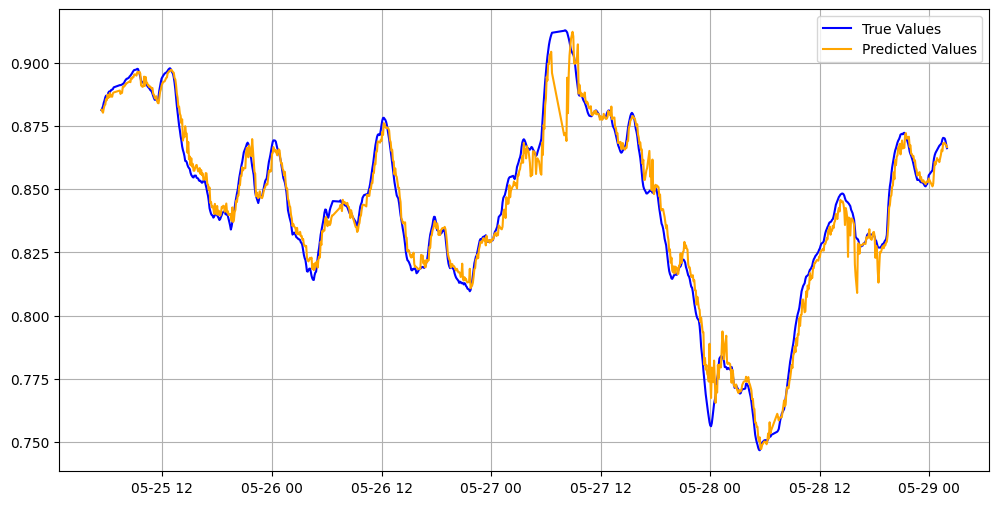

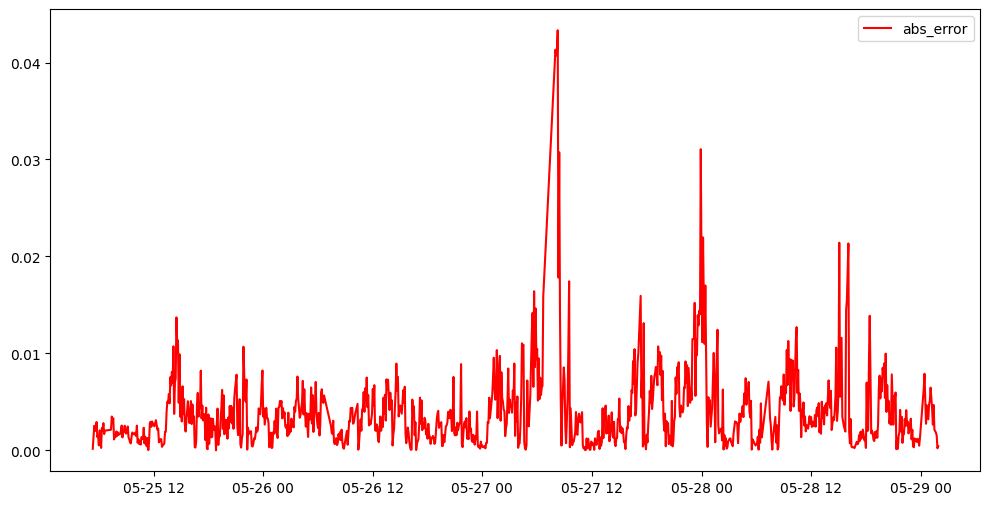

In [166]:
import matplotlib.pyplot as plt

# 畫圖
plt.figure(figsize=(12, 6))
plt.plot(result_df[y_col], label='True Values', color='blue')
plt.plot(result_df['prediction'], label='Predicted Values', color='orange')

plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(result_df['abs_error'], label='abs_error', color='red')#換個軸
plt.legend()
plt.show()


# 特徵重要度

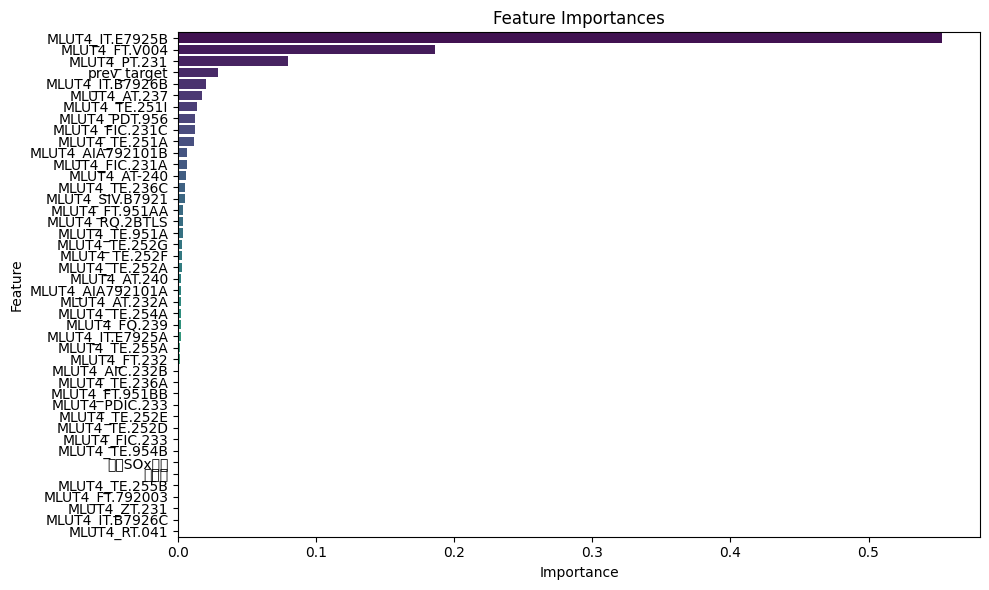

In [167]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 建立特徵重要度的 DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': train_X.columns,
    'Importance': current_model.feature_importances_
})

# 根據重要度排序
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 繪圖
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importances')
plt.tight_layout()
plt.show()


# 比較濾波效果

In [168]:
import matplotlib.pyplot as plt
select_df = df.loc[~df.index.isin(common_index), :]
select_df = select_df[features+[y_col]]
select_df = select_df.sort_index()
select_df = select_df[select_df[y_col]>0]
origin = select_df[y_col]
after_filter = apply_kalman_filter(select_df[y_col])

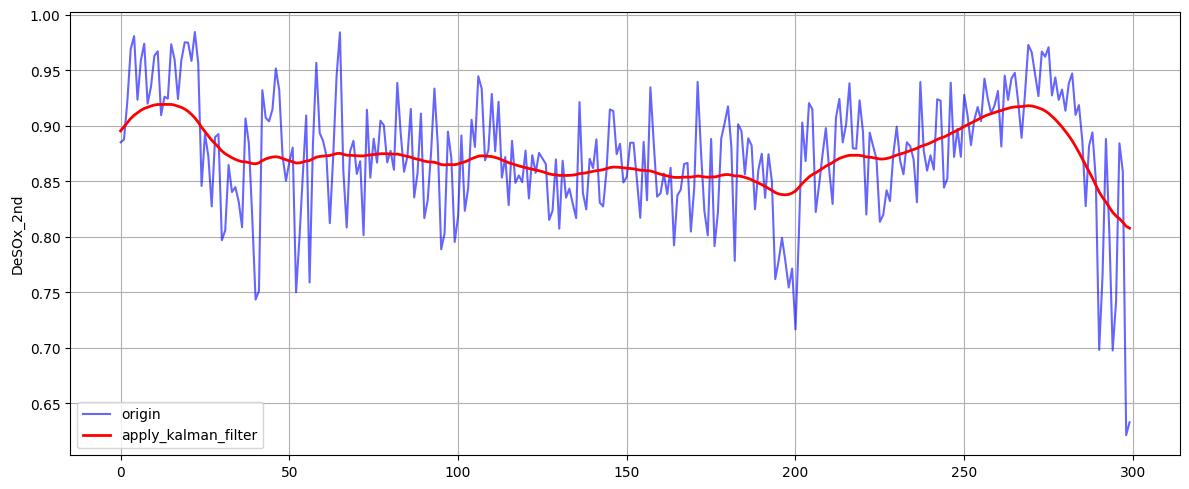

In [169]:
# 畫圖
plt.figure(figsize=(12, 5))
plt.plot(origin.values[-300:], label='origin', color='blue', alpha=0.6)
plt.plot(after_filter[-300:], label='apply_kalman_filter', color='red', linewidth=2)
plt.ylabel(y_col)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# y3

In [170]:
# 指標評估
y_true = result_df['MLUT4_AT-240']
y_pred = result_df['y3_prediction']

# Calculate R-squared
r2 = r2_score(y_true, y_pred)
# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
# Calculate MAPE
mape = np.mean(np.abs((y_true - y_pred) / y_true[y_true != 0])) * 100 if np.any(y_true != 0) else 0


# 假設 r2, rmse, mape 是事先計算好的指標
metrics = {
    'Metric': ['R-squared', 'RMSE', 'MAPE'],
    'Value': [r2, rmse, mape],
    'Unit': ['', '', '%']
}

df_metrics = pd.DataFrame(metrics)
df_metrics


,Metric,Value,Unit
0,R-squared,0.946339,
1,RMSE,0.378445,
2,MAPE,2.653889,%


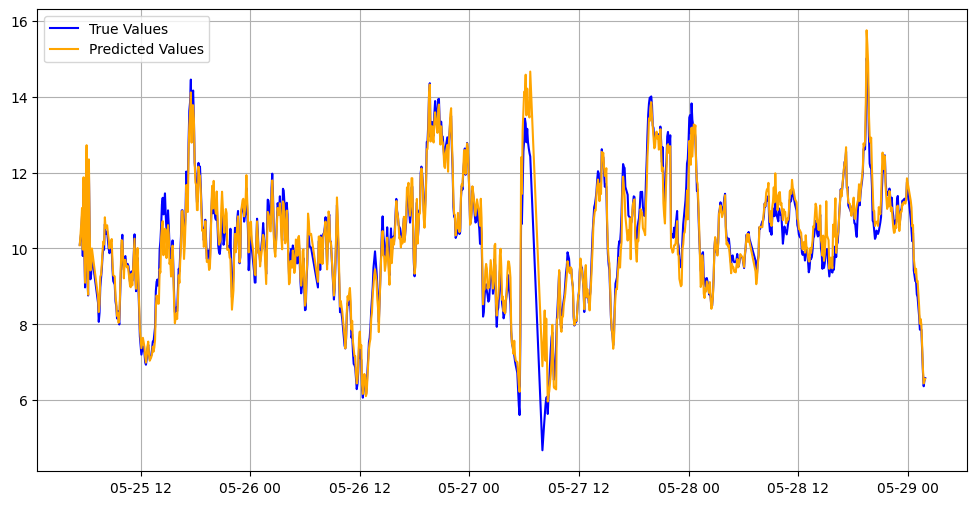

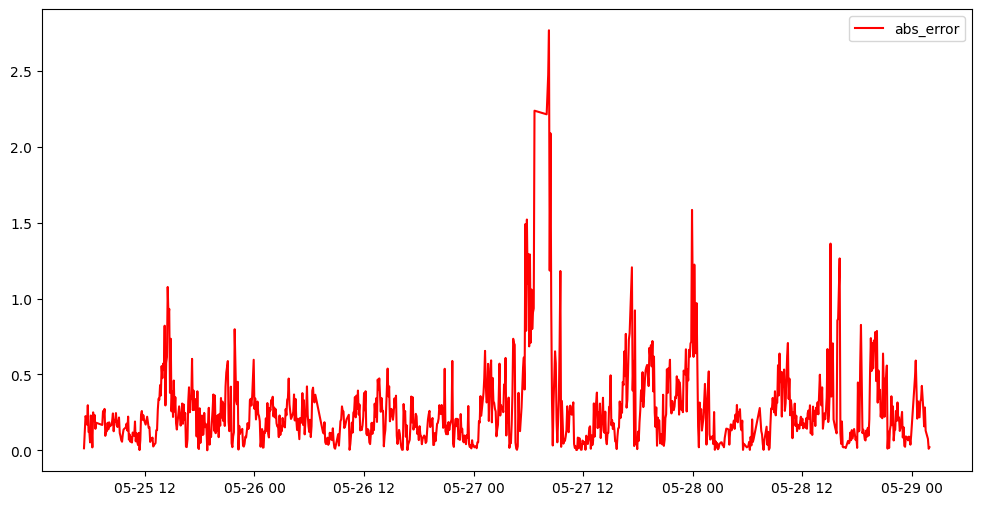

In [171]:
import matplotlib.pyplot as plt

# 畫圖
plt.figure(figsize=(12, 6))
plt.plot(result_df['MLUT4_AT-240'], label='True Values', color='blue')
plt.plot(result_df['y3_prediction'], label='Predicted Values', color='orange')

plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(result_df['y3_abs_error'], label='abs_error', color='red')#換個軸
plt.legend()
plt.show()
